# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)

print("Original label:", y_train[0])
print("One-hot encoded label:", y_train_one_hot[0])

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Original label: 9
One-hot encoded label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


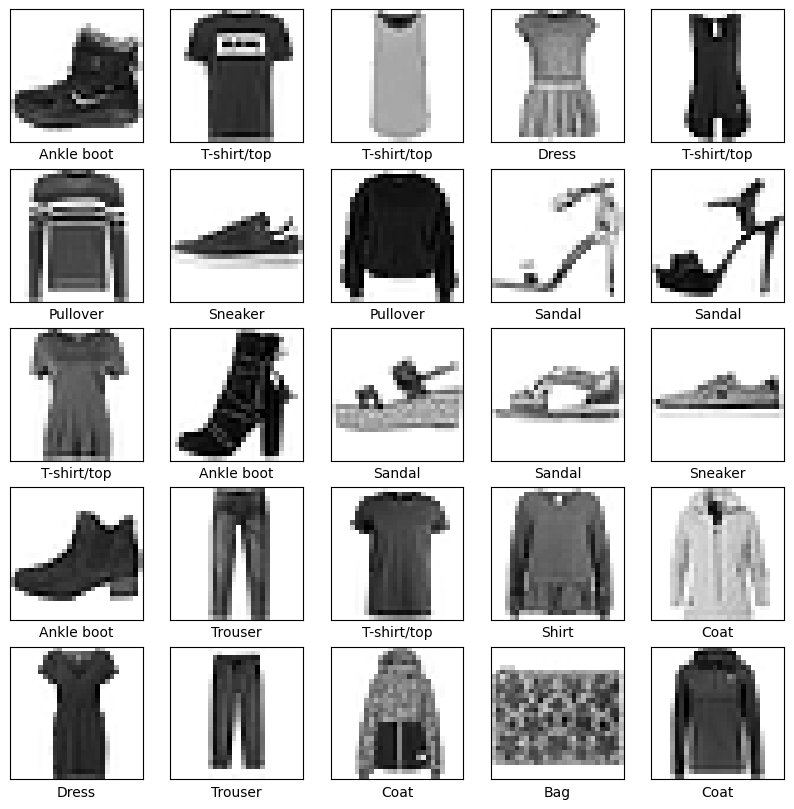


Pixel value statistics:
Min value: 0.0
Max value: 1.0
Mean value: 0.286
Std value: 0.353


In [3]:
import matplotlib.pyplot as plt

# Verify the data looks as expected
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

print("\nPixel value statistics:")
print(f"Min value: {X_train.min()}")
print(f"Max value: {X_train.max()}")
print(f"Mean value: {X_train.mean():.3f}")
print(f"Std value: {X_train.std():.3f}")

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

> Although the Fashion MNIST dataset images are suitable for model training and evaluation, their resolution and visual quality are limited.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.losses import CategoricalCrossentropy
from keras.optimizers import SGD

# 1. Build Linear Baseline Model
# This is a simple linear model (no hidden layers, no convolution)
model = Sequential([
    Flatten(input_shape=(28, 28)),       # Flatten 28x28 images into 1D vectors
    Dense(10, activation='linear')       # Linear output layer (10 classes)
])

# 2. Compile Model
# Using categorical crossentropy with logits for one-hot labels
model.compile(
    optimizer=SGD(),
    loss=CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 3. Train Model
history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# 4. Evaluate Model
test_loss_baseline, test_accuracy_baseline = model.evaluate(
    X_test,
    y_test_one_hot,
    verbose=0
)

# 5. Print Results
print(f'Loss:     {test_loss_baseline:.4f}')
print(f'Accuracy: {test_accuracy_baseline*100:.2f}%')

Epoch 1/10
 189/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.4164 - loss: 1.8426  

/Users/rajesh/Dropbox/GitHub/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 311us/step - accuracy: 0.7336 - loss: 0.8508 - val_accuracy: 0.7943 - val_loss: 0.6388
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - accuracy: 0.8039 - loss: 0.6048 - val_accuracy: 0.8137 - val_loss: 0.5644
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step - accuracy: 0.8187 - loss: 0.5523 - val_accuracy: 0.8210 - val_loss: 0.5324
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step - accuracy: 0.8271 - loss: 0.5243 - val_accuracy: 0.8237 - val_loss: 0.5086
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step - accuracy: 0.8307 - loss: 0.5060 - val_accuracy: 0.8318 - val_loss: 0.4950
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 277us/step - accuracy: 0.8355 - loss: 0.4924 - val_accuracy: 0.8347 - val_loss: 0.4844
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step - accuracy: 0.8382 - loss: 0.4827 - val_accuracy: 0.8333 - val_loss: 0.4806
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step - accuracy: 0.8411 - loss: 0.47

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

> The baseline linear model achieved ~80–83% accuracy, which aligns with expectations. While it captures basic pixel-level differences between classes, its inability to model spatial hierarchies and complex patterns limits its performance compared to CNNs.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [5]:
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense
from keras.optimizers import SGD

# 1. Preprocess Data
# Add channel dimension for Conv2D (grayscale images)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 2. Build CNN Model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    Flatten(),
    Dense(10, activation='softmax')  # Output layer: 10 classes
])

# 3. Compile Model
model.compile(
    optimizer=SGD(),
    loss='categorical_crossentropy',  # for one-hot labels
    metrics=['accuracy']
)

# 4. Train Model
history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# 5. Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)

print(f'Loss:     {test_loss:.4f}')
print(f'Accuracy: {test_accuracy*100:.2f}%')

Epoch 1/5
   1/1500 ━━━━━━━━━━━━━━━━━━━━ 3:05 123ms/step - accuracy: 0.1562 - loss: 2.3135

/Users/rajesh/Dropbox/GitHub/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7643 - loss: 0.6828 - val_accuracy: 0.8223 - val_loss: 0.5092
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8373 - loss: 0.4701 - val_accuracy: 0.8499 - val_loss: 0.4337
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8584 - loss: 0.4085 - val_accuracy: 0.8622 - val_loss: 0.3945
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8711 - loss: 0.3697 - val_accuracy: 0.8748 - val_loss: 0.3602
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8790 - loss: 0.3452 - val_accuracy: 0.8752 - val_loss: 0.3514
Loss:     0.3683
Accuracy: 87.15%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

> The CNN model outperformed the linear baseline by ~8–10% in test accuracy. This improvement is primarily due to the CNN's ability to learn spatial hierarchies in images, use shared convolutional filters, and apply non-linear transformations, which allows it to capture more complex patterns in the data compared to the simple linear model.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [6]:
# A. Test Hyperparameters
from tensorflow.keras import regularizers
from matplotlib import units

dense_units = [32, 64, 128]
results = {}
predictions = {}

for n_neuron in dense_units:
    model_name = f"dense_{n_neuron}"
    print(f'Testing model with {n_neuron} dense units')

    # Build Model
    model = Sequential()  # re-initialize the model
    model.add(Conv2D(n_neuron, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    # model.add(Conv2D(n_neuron, kernel_size=(3, 3), activation='relu'))  # optional second conv layer
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))  # Output layer with 10 classes

    # Compile Model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train Model
    model.fit(
        X_train,
        y_train_one_hot,
        epochs=10,
        batch_size=32,
        validation_split=0.2
    )

    # Evaluate Model
    loss, accuracy = model.evaluate(X_test, y_test_one_hot)
    y_pred = model.predict(X_test)

    # Store predictions and results
    predictions[model_name] = y_pred
    results[model_name + "_loss"] = loss
    results[model_name + "_accuracy"] = accuracy

# Print Results
print(f'dense_32_loss: {results["dense_32_loss"]}')
print(f'dense_64_loss: {results["dense_64_loss"]}')
print(f'dense_128_loss: {results["dense_128_loss"]}')

print(f'dense_32_accuracy: {results["dense_32_accuracy"]}')
print(f'dense_64_accuracy: {results["dense_64_accuracy"]}')
print(f'dense_128_accuracy: {results["dense_128_accuracy"]}')

Testing model with 32 dense units
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8534 - loss: 0.4157 - val_accuracy: 0.8818 - val_loss: 0.3256
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8966 - loss: 0.2900 - val_accuracy: 0.8862 - val_loss: 0.3133
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9079 - loss: 0.2547 - val_accuracy: 0.8966 - val_loss: 0.2873
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9188 - loss: 0.2271 - val_accuracy: 0.8929 - val_loss: 0.3027
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9265 - loss: 0.2047 - val_accuracy: 0.9011 - val_loss: 0.2884
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9339 - loss: 0.1855 - val_accuracy: 0.8975 - val_loss: 0.3023
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9407 - loss: 0.1671 - val_accuracy: 0.9026 - val_loss: 0.2953
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - 

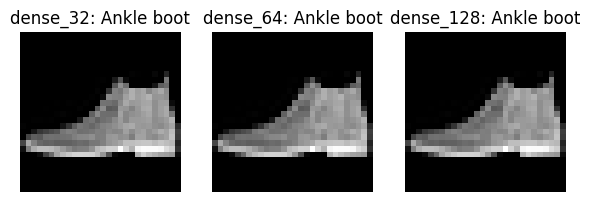

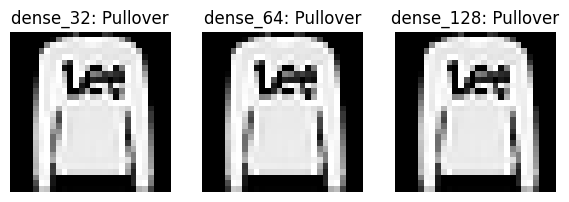

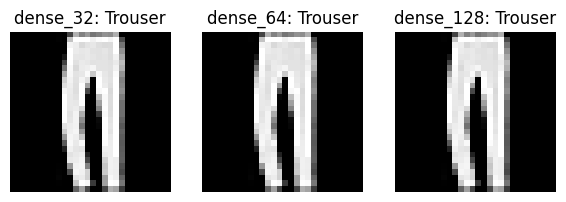

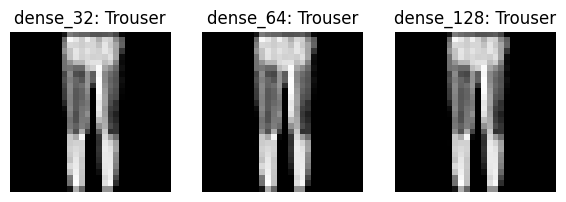

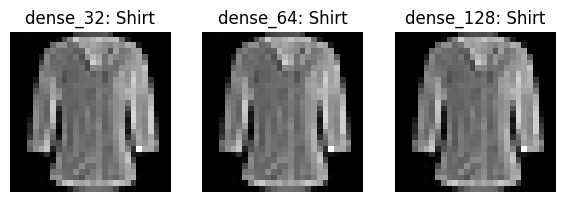

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize Predictions from Different Models
model_names = list(predictions.keys())

# Display the first 5 test images
for i in range(5):
    plt.figure(figsize=(12, 9))
    
    for model_name in model_names:
        # Create subplot: rows = number of models, columns = 5 images
        plt.subplot(len(model_names), 5, model_names.index(model_name) + 1)
        
        # Show the image
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        
        # Set title with model name and predicted class
        plt.title(f'{model_name}: {class_names[np.argmax(predictions[model_name][i])]}')
        plt.axis('off')

In [8]:
# B. Test Presence or Absence of Regularization
from keras.layers import Dropout
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense

# Dictionary to store results
regularization_results = {}

# 1. Model without Regularization
model = Sequential()
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))  # Output layer with 10 classes

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test_one_hot)
regularization_results["no_regularization"] = accuracy

# 2. Model with Dropout Regularization
model = Sequential()
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Dropout(0.5))  # Dropout regularization with rate 0.5
model.add(Flatten())
model.add(Dense(10, activation='softmax'))  # Output layer with 10 classes

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    X_train,
    y_train_one_hot,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test_one_hot)
regularization_results["with_dropout"] = accuracy

# 3. Print Results
for model_name, val_acc in regularization_results.items():
    print(f'{model_name}: Validation Accuracy = {val_acc:.4f}')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8574 - loss: 0.4020 - val_accuracy: 0.8870 - val_loss: 0.3194
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8994 - loss: 0.2828 - val_accuracy: 0.8945 - val_loss: 0.2970
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9141 - loss: 0.2379 - val_accuracy: 0.8982 - val_loss: 0.2862
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9247 - loss: 0.2062 - val_accuracy: 0.9013 - val_loss: 0.2861
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9357 - loss: 0.1784 - val_accuracy: 0.8995 - val_loss: 0.2897
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9430 - loss: 0.1573 - val_accuracy: 0.9022 - val_loss: 0.2980
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9515 - loss: 0.1361 - val_accuracy: 0.9008 - val_loss: 0.3074
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9549 - loss: 0.1235 - 

Text(0.5, 1.0, 'Loss - With Regularization')

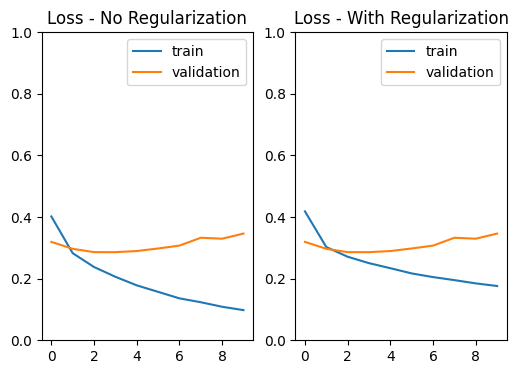

In [9]:
import matplotlib.pyplot as plt

# Plot Training and Validation Loss
plt.figure(figsize=(6, 4))

# 1. Loss - No Regularization
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 1)
plt.legend(loc='best')
plt.title('Loss - No Regularization')

# 2. Loss - With Regularization
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 1)
plt.legend(loc='best')
plt.title('Loss - With Regularization')

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

> Model performance showed modest differences with filter number and dropout (0.5), with test accuracies around 85–89% and loss ~0.4. Further tuning of optimizers, activations, or adding hidden layers could push accuracy above 90% and reduce loss. Train accuracies were generally higher than test, indicating some overfitting.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, Dropout, Flatten, Dense

# Build Final CNN Model with Dropout
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Dropout(0.5))  # Dropout regularization
model.add(Flatten())
model.add(Dense(10, activation='softmax'))  # Output layer with 10 classes

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history_final = model.fit(
    X_train,
    y_train_one_hot,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test_one_hot)
print(f"Test Loss: {loss:.3f}")
print(f"Test Accuracy: {accuracy:.3f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8456 - loss: 0.4362 - val_accuracy: 0.8813 - val_loss: 0.3363
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8851 - loss: 0.3212 - val_accuracy: 0.8911 - val_loss: 0.3065
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8947 - loss: 0.2897 - val_accuracy: 0.8946 - val_loss: 0.2933
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9027 - loss: 0.2697 - val_accuracy: 0.8937 - val_loss: 0.2996
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9068 - loss: 0.2558 - val_accuracy: 0.8950 - val_loss: 0.2942
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9144 - loss: 0.2388 - val_accuracy: 0.8970 - val_loss: 0.2943
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9156 - loss: 0.2314 - val_accuracy: 0.9010 - val_loss: 0.2861
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9178 - loss: 0.2214 - 

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

> The model performed much better than the baseline linear regression and slightly better than the initial CNN model. Using Adam instead of SGD improved performance, and adding additional hidden layers could further help.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.